# Reference

In [1]:
#user = r"\SagixOffice"  # HomeOffice
user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import src.transitions as tr
import src.miscellaneous as mi
import src.fluorophores as fl
import src.statistics as st
import src.simulation as si
import src.emissions as em
import src.blinking as bl
import src.tcspc as tc
import src.fcs as fc
import src.figure as fi

import numpy as np

%load_ext autoreload
%autoreload 2

C:\Users\vie43sq\Miniconda3\envs\MarkovModels\lib\site-packages\pycorrelate\pycorrelate.py:118: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def ucorrelate(t, u, maxlag=None):


In [4]:
number_fluorophores = 1
bleaching = False

irradiance = 2.5
wavelength = 640

photon_collection_rate = 0.01
emccd_gain = 100
resample = '1ms'

end_time = 20000
seed = 3

In [6]:
fluorophore = fl.construct_fluorophores('cy5', 1, number_fluorophores)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophore)

transitions = tr.load_transitions(fluorophore_system, irradiance=irradiance, wavelength=wavelength, bleaching=bleaching)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
simulation = si.Simulation(transition_set)
simulation.run(size=int(1e7), end_time=end_time, seed=seed, use_memmap=r'D:\memmaps\run 2')
emissions = em.Emissions(simulation, photon_collection_rate=photon_collection_rate, resample=resample,
                         emccd_gain=emccd_gain, seed=4)
lifetimes = st.get_fluorescence_lifetime(simulation)
blinking = bl.Blinking(emissions)
fcs = fc.FCS(emissions).autocorrelate_time_points(exp_min=-7, exp_max=1)
simulation.delete_memmaps()

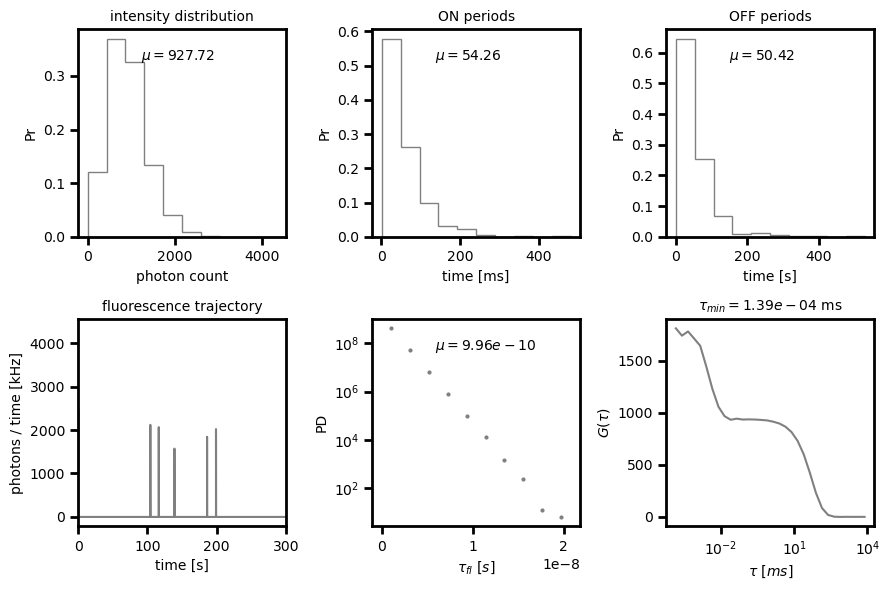

In [12]:
axes = emissions.plot(ncols=3, nrows=2, fig_width=9, fig_height=6, mode='histogram', histtype='step', fontsize=10, density=False, color='grey',
                         display_mean=True)
blinking.plot(axes=axes[0, 1], color='grey', mode='on_histogram', histtype='step', fontsize=10, display_mean=True, density=False, as_time='ms')
blinking.plot(axes=axes[0, 2], color='grey', mode='off_histogram', histtype='step', fontsize=10, display_mean=True, density=False, as_time='s')
emissions.plot(mode='time_series', color='grey', fontsize=10, ylabel='photons / time [kHz]', xlim=[0, 300], axes=axes[1, 0])
fi.universal_figure(type_='hist', data=[lifetimes], ylabel='PD', density=True, xlabel=r'$\tau_{fl} \ [s] $', histtype='dot', yscale='log',
                   axes=axes[1, 1], color='grey', fontsize=10)
axes[1, 1].text(x=0.3, y=0.85, s=fr'$\mu = {lifetimes.mean():.2e}$', transform=axes[1, 1].transAxes)
fcs.plot(axes=axes[1, 2], color='grey', fontsize=10, unit='ms')
axes[0, 0].get_figure().tight_layout()

In [18]:
print(f'{blinking.on_periods.size/20} ON events per 1000 s')

19.85 ON events per 1000 s


In [19]:
number_fluorophores = 2

In [23]:
fluorophore = fl.construct_fluorophores('cy5', 1, number_fluorophores)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophore)

transitions = tr.load_transitions(fluorophore_system, irradiance=irradiance, wavelength=wavelength, bleaching=bleaching)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
remove_transitions = ['OFRET', 'HFRET', 'CFRET', 'STA']
transition_set = transition_set.filter_by_abbreviation(remove_list=remove_transitions)
transition_set.finalize()
simulation = si.Simulation(transition_set)
simulation.run(size=int(1e7), end_time=end_time, seed=seed, use_memmap=r'D:\memmaps\run 1')
emissions = em.Emissions(simulation, photon_collection_rate=photon_collection_rate, resample=resample,
                         emccd_gain=emccd_gain, seed=4)
lifetimes = st.get_fluorescence_lifetime(simulation)
blinking = bl.Blinking(emissions)
fcs = fc.FCS(emissions).autocorrelate_time_points(exp_min=-7, exp_max=1)
simulation.delete_memmaps()

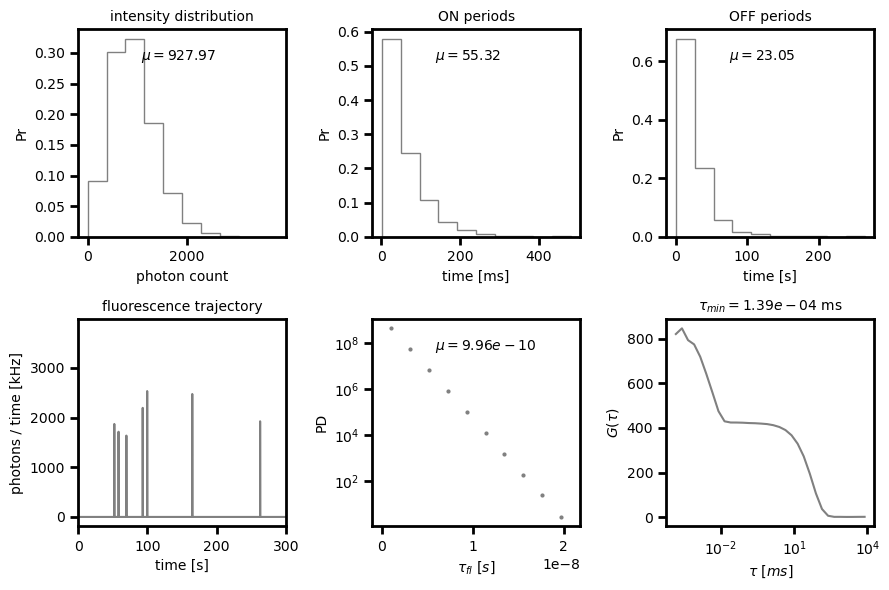

In [24]:
axes = emissions.plot(ncols=3, nrows=2, fig_width=9, fig_height=6, mode='histogram', histtype='step', fontsize=10, density=False, color='grey',
                         display_mean=True)
blinking.plot(axes=axes[0, 1], color='grey', mode='on_histogram', histtype='step', fontsize=10, display_mean=True, density=False, as_time='ms')
blinking.plot(axes=axes[0, 2], color='grey', mode='off_histogram', histtype='step', fontsize=10, display_mean=True, density=False, as_time='s')
emissions.plot(mode='time_series', color='grey', fontsize=10, ylabel='photons / time [kHz]', xlim=[0, 300], axes=axes[1, 0])
fi.universal_figure(type_='hist', data=[lifetimes], ylabel='PD', density=True, xlabel=r'$\tau_{fl} \ [s] $', histtype='dot', yscale='log',
                   axes=axes[1, 1], color='grey', fontsize=10)
axes[1, 1].text(x=0.3, y=0.85, s=fr'$\mu = {lifetimes.mean():.2e}$', transform=axes[1, 1].transAxes)
fcs.plot(axes=axes[1, 2], color='grey', fontsize=10, unit='ms')
axes[0, 0].get_figure().tight_layout()

In [25]:
print(f'{blinking.on_periods.size/20} ON events per 1000 s')

43.25 ON events per 1000 s


In [26]:
number_fluorophores = 3

In [27]:
fluorophore = fl.construct_fluorophores('cy5', 1, number_fluorophores)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophore)

transitions = tr.load_transitions(fluorophore_system, irradiance=irradiance, wavelength=wavelength, bleaching=bleaching)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
remove_transitions = ['OFRET', 'HFRET', 'CFRET', 'STA']
transition_set = transition_set.filter_by_abbreviation(remove_list=remove_transitions)
transition_set.finalize()
simulation = si.Simulation(transition_set)
simulation.run(size=int(1e7), end_time=end_time, seed=seed, use_memmap=r'D:\memmaps\run 2')
emissions = em.Emissions(simulation, photon_collection_rate=photon_collection_rate, resample=resample,
                         emccd_gain=emccd_gain, seed=4)
lifetimes = st.get_fluorescence_lifetime(simulation)
blinking = bl.Blinking(emissions)
fcs = fc.FCS(emissions).autocorrelate_time_points(exp_min=-7, exp_max=1)
simulation.delete_memmaps()

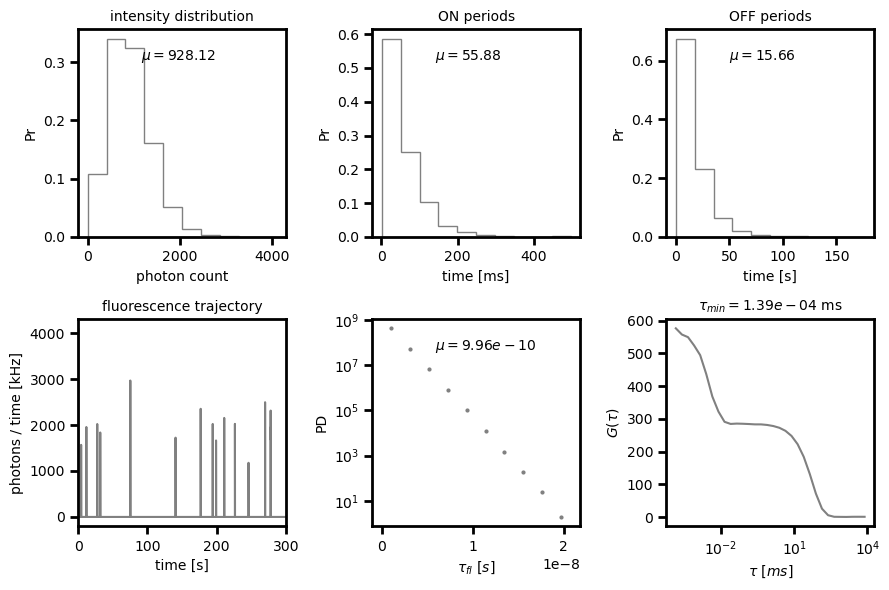

In [28]:
axes = emissions.plot(ncols=3, nrows=2, fig_width=9, fig_height=6, mode='histogram', histtype='step', fontsize=10, density=False, color='grey',
                         display_mean=True)
blinking.plot(axes=axes[0, 1], color='grey', mode='on_histogram', histtype='step', fontsize=10, display_mean=True, density=False, as_time='ms')
blinking.plot(axes=axes[0, 2], color='grey', mode='off_histogram', histtype='step', fontsize=10, display_mean=True, density=False, as_time='s')
emissions.plot(mode='time_series', color='grey', fontsize=10, ylabel='photons / time [kHz]', xlim=[0, 300], axes=axes[1, 0])
fi.universal_figure(type_='hist', data=[lifetimes], ylabel='PD', density=True, xlabel=r'$\tau_{fl} \ [s] $', histtype='dot', yscale='log',
                   axes=axes[1, 1], color='grey', fontsize=10)
axes[1, 1].text(x=0.3, y=0.85, s=fr'$\mu = {lifetimes.mean():.2e}$', transform=axes[1, 1].transAxes)
fcs.plot(axes=axes[1, 2], color='grey', fontsize=10, unit='ms')
axes[0, 0].get_figure().tight_layout()

In [30]:
print(f'{blinking.on_periods.size/20} ON events per 1000 s')

63.65 ON events per 1000 s


In [31]:
end_time = 1000
number_fluorophores = 3

In [34]:
fluorophore = fl.construct_fluorophores('cy5', 1, number_fluorophores)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophore)

transitions = tr.load_transitions(fluorophore_system, irradiance=irradiance, wavelength=wavelength, bleaching=bleaching)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
remove_transitions = ['OFRET', 'HFRET', 'CFRET', 'STA']
transition_set = transition_set.filter_by_abbreviation(remove_list=remove_transitions)
transition_set.finalize()
simulation = si.Simulation(transition_set)
simulation.run(size=int(1e7), end_time=end_time, seed=seed, use_memmap=r'D:\memmaps\run 1')
emissions = em.Emissions(simulation, photon_collection_rate=photon_collection_rate, resample=resample,
                         emccd_gain=emccd_gain, seed=4)
lifetimes = st.get_fluorescence_lifetime(simulation)
blinking = bl.Blinking(emissions)
fcs = fc.FCS(emissions).autocorrelate_time_points(exp_min=-7, exp_max=1)

In [35]:
times_1, values_1 = bl.get_off_statistics(simulation, 0, event_indices=emissions.event_indices)
times_2, values_2 = bl.get_off_statistics(simulation, 1, event_indices=emissions.event_indices)

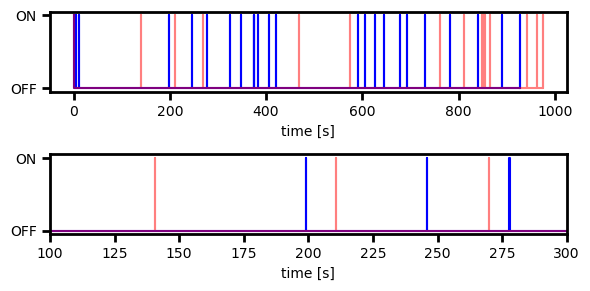

In [38]:
axes = fi.universal_figure(nrows=2, type_='line', data=[times_1, values_1])
fi.universal_figure(type_='line', data=[times_2, values_2], axes=axes[0, 0], color='r', alpha=0.5,
                   xlabel='time [s]', ylabel='', yticks=[0, 1], yticklabels={'labels':['OFF', 'ON']}, fontsize=10)
fi.universal_figure(type_='line', data=[times_1, values_1], xlim=[100, 300], axes=axes[1, 0])
fi.universal_figure(type_='line', data=[times_2, values_2], xlim=[100, 300], axes=axes[1, 0],
                   color='r', alpha=0.5, fontsize=10,
                   xlabel='time [s]', ylabel='', yticks=[0, 1], yticklabels={'labels':['OFF', 'ON']})
axes[0, 0].get_figure().tight_layout()